In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

from adserve_sim.data.download import RAW_DIR, RAW_FILENAME
from adserve_sim.data.schema import (
    CATEGORICAL_COLUMNS,
    LABEL,
    RAW_HOUR,
    TIMESTAMP,
)

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (10, 4)

# Avazu EDA

**adserve-sim** replays real ad-request logs and asks: if a click model ranks impressions correctly but predicts the wrong probabilities, what does that cost once bids compete for a slot? AUC can't see this on its own as it's invariant to any monotone rescaling of the predictions, but `bid = value x pCTR` means a systematic probability error becomes a systematic bidding error.

Everything in this notebook is currently a hardcoded assumption in `src/`, written from Avazu's published schema rather than the actual file. This notebook confirms or breaks each one against the real data. No modeling here, just looking.

Data: `data/processed/avazu_sample.parquet`, produced by
```
uv run python -m adserve_sim.data.download --sample-rows 200000
```
(a per-hour stratified sample of the ~40M-row raw file).

In [2]:
SAMPLE_PATH = Path("../data/processed/avazu_sample.parquet")

if not SAMPLE_PATH.exists():
    raise FileNotFoundError(
        f"{SAMPLE_PATH} not found. Run:\n"
        "  uv run python -m adserve_sim.data.download --sample-rows 200000"
    )

df = pd.read_parquet(SAMPLE_PATH)
print(f"{len(df):,} rows, {df[TIMESTAMP].min()} to {df[TIMESTAMP].max()}")
df.head()

199,992 rows, 2014-10-21 00:00:00 to 2014-10-30 23:00:00


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,timestamp
0,6894871064028562036,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,c51f82bc,d9b5648e,0f2161f8,a99f214a,132f67d7,f4fffcd0,1,0,20984,320,50,2371,0,551,100215,46,2014-10-21
1,17836777713026597863,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,98fed791,d9b5648e,0f2161f8,a99f214a,7be82ca6,f51246a7,1,0,19743,320,50,2264,3,427,100002,61,2014-10-21
2,14392980953308022152,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,e417c1aa,c6263d8a,1,0,15708,320,50,1722,0,35,-1,79,2014-10-21
3,10526028123284470117,0,14102100,1005,1,5114c672,3f2f3819,3e814130,ecad2386,7801e8d9,07d7df22,a99f214a,36f92b25,d7bc6ccb,1,0,19772,320,50,2227,0,687,100074,48,2014-10-21
4,11022867415363077244,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,51cedd4e,aefc06bd,0f2161f8,a99f214a,f862c1f2,e3bb76b5,1,0,21611,320,50,2480,3,297,100111,61,2014-10-21


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199992 entries, 0 to 199991
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                199992 non-null  object        
 1   click             199992 non-null  int8          
 2   hour              199992 non-null  object        
 3   C1                199992 non-null  object        
 4   banner_pos        199992 non-null  object        
 5   site_id           199992 non-null  object        
 6   site_domain       199992 non-null  object        
 7   site_category     199992 non-null  object        
 8   app_id            199992 non-null  object        
 9   app_domain        199992 non-null  object        
 10  app_category      199992 non-null  object        
 11  device_id         199992 non-null  object        
 12  device_ip         199992 non-null  object        
 13  device_model      199992 non-null  object        
 14  devi

## 1. Base CTR

Synthetic fixtures used ~17% to keep small samples from being all-zero. Real
display CTR is typically far lower (0.1–0.5%) so the fixtures were expected
to be wildly optimistic.

They aren't, and the reason matters. [Kaggle's data description](https://www.kaggle.com/competitions/avazu-ctr-prediction/data) states clicks
and non-clicks were subsampled at *different* rates before release, so the
file's click rate is inflated relative to the traffic it came from.

This has a direct consequence for a project about calibration. A model fitted
here is calibrated to the **sampled** distribution, not to real traffic. Its
probabilities are correct for this file and systematically too high for the
world. That is a known, correctable bias (the fix is a log-odds offset of
`log(sampling_rate_ratio)`), but the ratio isn't published, so it can't be
undone.

What survives: *relative* calibration comparisons. Isotonic versus Platt versus
raw, and the revenue gap between calibrated and uncalibrated, are all valid
because both sides sit in the same distorted distribution. What doesn't survive
is any claim about absolute click probabilities.

In [4]:
base_ctr = df[LABEL].mean()
n_clicks = int(df[LABEL].sum())
print(f"base CTR: {base_ctr:.4%}  ({n_clicks:,} clicks / {len(df):,} impressions)")

base CTR: 16.9077%  (33,814 clicks / 199,992 impressions)


## 2. Cardinality per categorical

The step-3 encoding decision (CatBoost's native categorical handling vs. a hand-written out-of-fold encoder) is justified by `device_ip` / `device_id` running to "millions" of distinct values. Check that against the sample (note cardinality in a 200k-row sample is a lower bound on the full 40M-row file's true cardinality, not the answer itself).

In [5]:
cardinality = df[list(CATEGORICAL_COLUMNS)].nunique().sort_values(ascending=False)

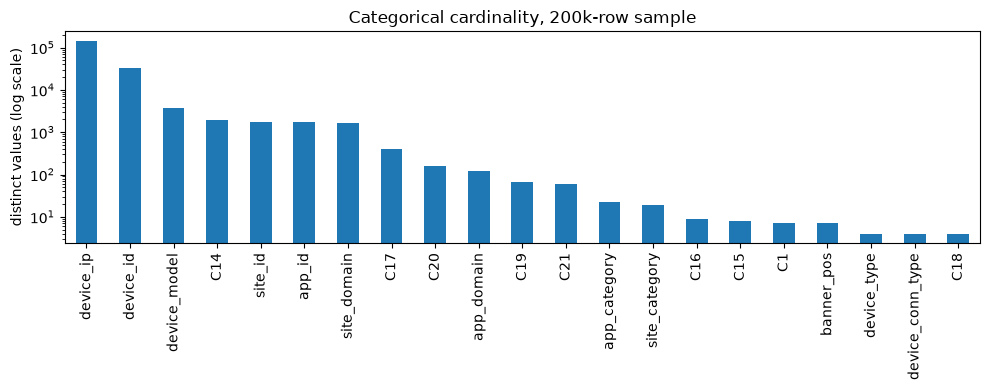

device_ip           143551
device_id            33074
device_model          3756
C14                   1904
site_id               1783
app_id                1734
site_domain           1676
C17                    408
C20                    158
app_domain             119
C19                     65
C21                     60
app_category            23
site_category           19
C16                      9
C15                      8
C1                       7
banner_pos               7
device_type              4
device_conn_type         4
C18                      4
dtype: int64

In [6]:
ax = cardinality.plot(kind="bar")
ax.set_yscale("log")
ax.set_ylabel("distinct values (log scale)")
ax.set_title("Categorical cardinality, 200k-row sample")
plt.tight_layout()
plt.show()

display(cardinality)

`singleton_share` is the fraction of a column's *values* seen exactly once.
`rows_in_singletons` is the fraction of *impressions* sitting on such a value, which is
the more useful number because it says how much of the data a naive target
encoder would encode with that row's own label and nothing else.

This is the concrete justification for out-of-fold encoding in
`features/build.py`, and for the smoothing prior: a category seen once is not
evidence of a 0% or 100% click rate, it is evidence of nothing.

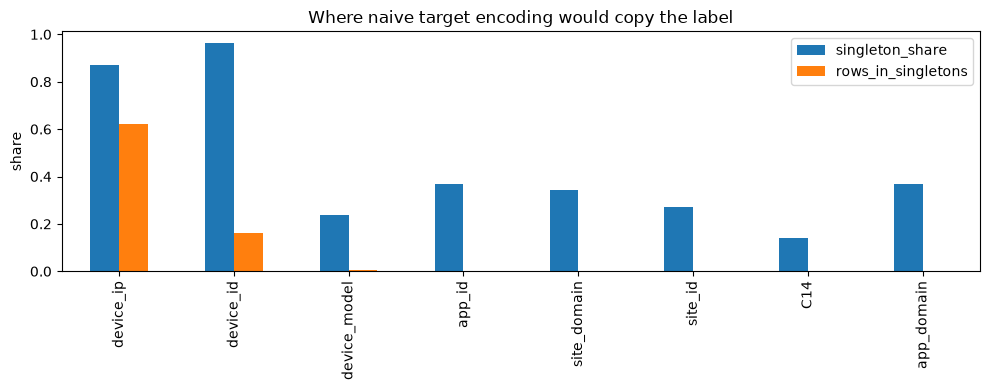

,n_unique,singleton_share,rows_in_singletons
device_ip,143551,0.868862,0.623655
device_id,33074,0.964595,0.159521
device_model,3756,0.238285,0.004475
app_id,1734,0.367359,0.003185
site_domain,1676,0.344869,0.002890
site_id,1783,0.271453,0.002420
C14,1904,0.140231,0.001335
app_domain,119,0.369748,0.000220


In [7]:
singletons = pd.DataFrame(
    {
        "n_unique": df[col].nunique(),
        "singleton_share": (df[col].value_counts() == 1).mean(),
        "rows_in_singletons": (df[col].value_counts() == 1).sum() / len(df),
    }
    for col in CATEGORICAL_COLUMNS
).set_index(pd.Index(CATEGORICAL_COLUMNS))

singletons = singletons.sort_values("rows_in_singletons", ascending=False)

ax = singletons[["singleton_share", "rows_in_singletons"]].head(8).plot(kind="bar")
ax.set_ylabel("share")
ax.set_title("Where naive target encoding would copy the label")
plt.tight_layout()
plt.show()

display(singletons.head(8))

The two bars answer different questions and `device_id` shows why both matter.
96% of its distinct values appear once, but those account for only 16% of
impressions, a few heavily-repeated IDs carry most of the traffic. `device_ip`
is the opposite: fewer singleton values proportionally, but they cover 62% of
all rows.

`rows_in_singletons` is the one that bounds the damage, because it says what
fraction of the training set a naive encoder would hand its own label.

## 3 & 4. Does `hour` parse cleanly, and is there a real daily rhythm?

Both questions are about the `hour` column at full scale, not just the sample, and both are cheap to check with a single column-limited scan of the raw file, so they share one pass here.

**On parsing:** `prepare_sample` calls `parse_hour` once on the fully concatenated frame and raises on the first failure. Two readings of that: if `avazu_sample.parquet` exists at all, every row in the raw file already parsed successfully, the check below is a genuine confirmation (with a row count), not a vacuous one, but it can't surface *partial* failures the way a non-raising per-row scan can.

**On volume:** the stratified sampler in `download.py` preserves the hourly volume curve on the assumption that it's not flat and is therefore worth preserving. This confirms there's a real curve to preserve in the first place, and how much it varies across the 10 days.

In [8]:
raw_path = Path("..") / RAW_DIR / RAW_FILENAME

total_rows = 0
bad_hour_values: set[str] = set()
hour_counts = pd.Series(dtype="int64")

reader = pd.read_csv(
    raw_path,
    usecols=[RAW_HOUR],
    dtype={RAW_HOUR: "str"},
    chunksize=1_000_000,
    compression="infer",
)
for chunk in reader:
    parsed = pd.to_datetime(chunk[RAW_HOUR], format="%y%m%d%H", errors="coerce")
    total_rows += len(chunk)
    bad_hour_values.update(chunk.loc[parsed.isna(), RAW_HOUR].unique())
    hour_counts = hour_counts.add(parsed.value_counts(), fill_value=0)

hour_counts = hour_counts.sort_index()
print(f"{total_rows:,} rows scanned")
print(
    f"{len(bad_hour_values)} distinct unparseable hour value(s)"
    + (f": {list(bad_hour_values)[:10]}" if bad_hour_values else "")
)

40,428,967 rows scanned
0 distinct unparseable hour value(s)


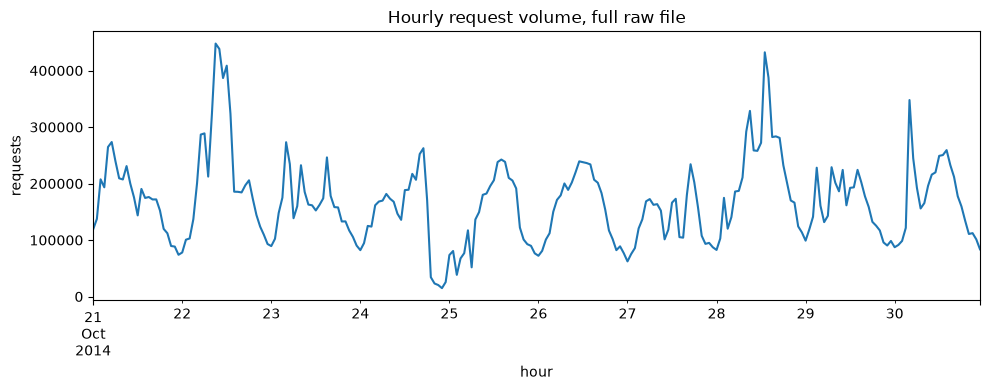

day-to-day coefficient of variation: 0.185


hour
2014-10-21    4122995.0
2014-10-22    5337126.0
2014-10-23    3870752.0
2014-10-24    3335302.0
2014-10-25    3363122.0
2014-10-26    3835892.0
2014-10-27    3225010.0
2014-10-28    5287222.0
2014-10-29    3832608.0
2014-10-30    4218938.0
dtype: float64

In [9]:
ax = hour_counts.plot()
ax.set_ylabel("requests")
ax.set_title("Hourly request volume, full raw file")
plt.tight_layout()
plt.show()

daily = hour_counts.groupby(hour_counts.index.normalize()).sum()
cv = daily.std() / daily.mean()
print(f"day-to-day coefficient of variation: {cv:.3f}")
daily

## 5. Are `C14`-`C21` genuinely categorical?

Spearman's rho measures whether CTR moves *consistently* up or down with the
numeric value, without assuming the relationship is a straight line. Near +1 or
-1 means the ordering carries information; near 0 means the numbers are just
labels.

The bucket count is the catch. `C15`, `C16` and `C18` have so few distinct
values that they collapse to two buckets, and any two points lie on a monotone
line — so those panels look like the cleanest evidence in the grid while being
the only ones that cannot be evidence of anything. They are marked inconclusive
rather than scored.

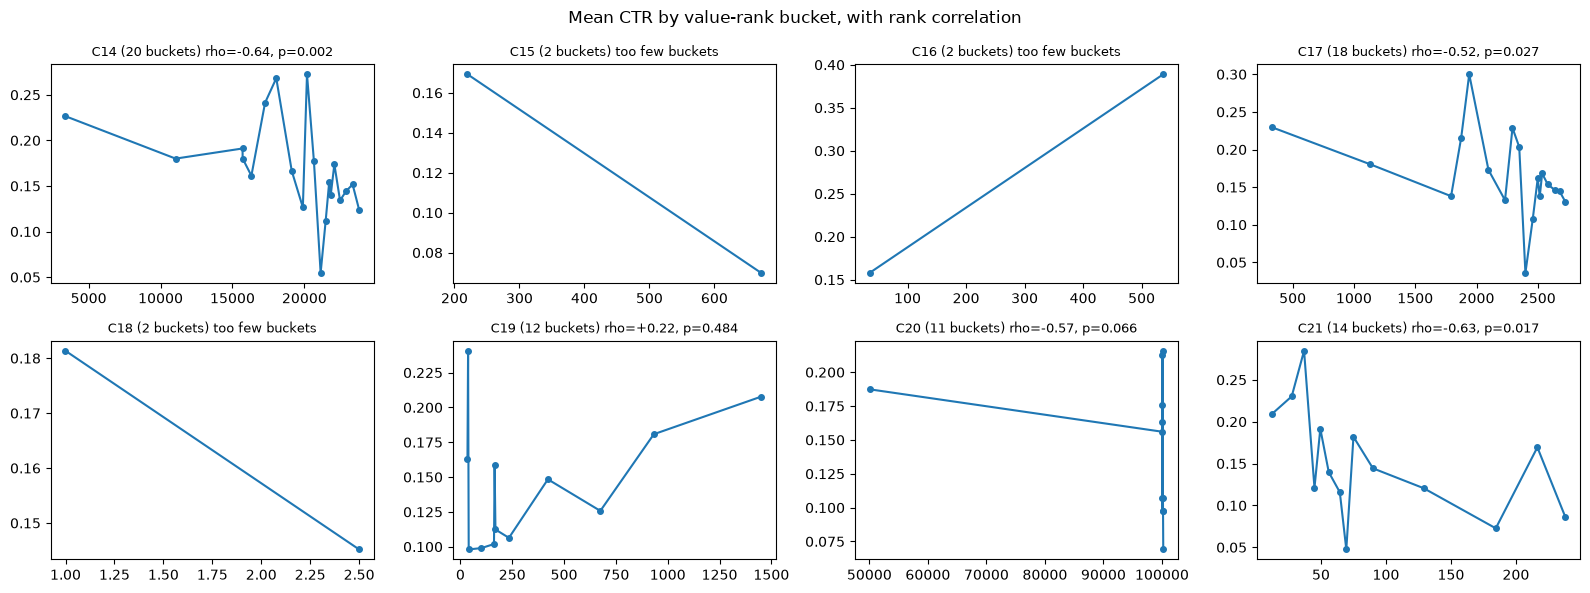

,n_buckets,spearman
column,,
C14,20,-0.639098
C15,2,NaN
C16,2,NaN
C17,18,-0.521156
C18,2,NaN
C19,12,0.223776
C20,11,-0.572727
C21,14,-0.626374


In [10]:
MIN_BUCKETS = 5

c_columns = [c for c in CATEGORICAL_COLUMNS if c.startswith("C") and c != "C1"]
results = []

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, c_columns, strict=False):
    values = df[col].astype(int)
    buckets = pd.qcut(values, q=min(20, values.nunique()), duplicates="drop")
    stats = df.groupby(buckets, observed=True)[LABEL].agg(["mean", "count"])
    midpoints = [interval.mid for interval in stats.index]

    if len(stats) >= MIN_BUCKETS:
        rho, pvalue = spearmanr(midpoints, stats["mean"])
        verdict = f"rho={rho:+.2f}, p={pvalue:.3f}"
    else:
        rho, verdict = float("nan"), "too few buckets"

    results.append({"column": col, "n_buckets": len(stats), "spearman": rho})

    ax.plot(midpoints, stats["mean"], marker="o", markersize=4)
    ax.set_title(f"{col} ({len(stats)} buckets) {verdict}", fontsize=9)

fig.suptitle("Mean CTR by value-rank bucket, with rank correlation")
plt.tight_layout()
plt.show()

display(pd.DataFrame(results).set_index("column"))

Four of eight show significant negative rank correlation, so the "all
categorical" assumption in `RAW_DTYPES` is partially wrong: C14, C17, C20 and
C21 carry ordering that `str` encoding throws away.

Two caveats on how far to trust this. The test runs over 20 bucket means, not
200k rows, so n is small and individual p-values are weak. And a monotone trend
in bucket means is consistent with ordinality but also with a few high-volume
buckets pulling the line, the panels wiggle inside the broad trend.

The actionable version is an experiment, not a conclusion: pass C14, C17, C20,
C21 as numeric alongside their categorical encoding and compare AUC. That is
one more MLflow run at step 3, and it either helps or it doesn't. 

## 6. Base rate stability across days

`split.py` cuts train/validation/test on day boundaries. That's the right call for avoiding leakage, but it's only free of a second problem -- distribution shift -- if the click-through rate doesn't move much day to day. If it does, some of what later looks like a calibration problem could just be this.

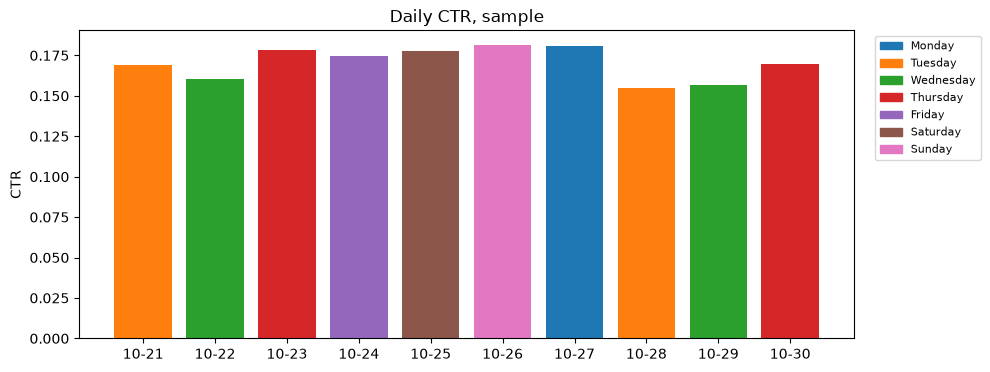

In [12]:
daily_ctr = df.groupby(df[TIMESTAMP].dt.normalize())[LABEL].mean()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
palette = plt.get_cmap("tab10")
color_by_weekday = dict(zip(weekday_order, [palette(i) for i in range(7)], strict=True))
bar_colors = [color_by_weekday[day] for day in daily_ctr.index.day_name()]

fig, ax = plt.subplots()
ax.bar(daily_ctr.index.strftime("%m-%d"), daily_ctr.values, color=bar_colors)
ax.set_ylabel("CTR")
ax.set_title("Daily CTR, sample")
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_by_weekday[day]) for day in weekday_order]
ax.legend(legend_handles, weekday_order, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()

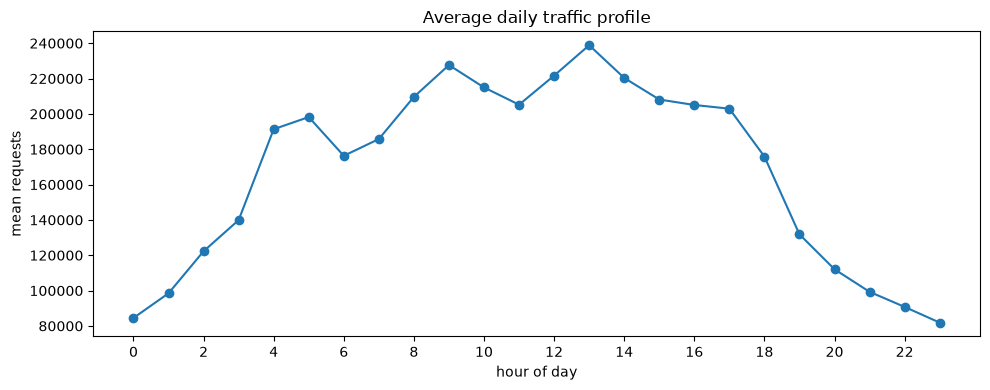

peak/trough ratio: 2.9x


In [13]:
profile = hour_counts.groupby(hour_counts.index.hour).mean()

ax = profile.plot(marker="o")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean requests")
ax.set_title("Average daily traffic profile")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

print(f"peak/trough ratio: {profile.max() / profile.min():.1f}x")

The raw series above is noisy; this is the same data folded into an average
day. The peak-to-trough ratio is what a budget pacing controller has to spend
against, a campaign that spends at a flat hourly rate will exhaust early on
quiet hours and underspend at peak.

Note the timestamps carry no timezone, so "hour 0" is whatever clock Avazu
recorded in. The shape is usable; the absolute hours are not interpretable.

Peak-to-trough is roughly 2.9x, so a campaign spending at a flat hourly rate
would underspend at peak and exhaust early in quiet hours, this curve is what
a pacing controller has to spend against.

The shape is worth not over-reading. Traffic rises through the morning and
falls after hour 18, which is not the evening-heavy pattern real mobile usage
shows. The timestamps carry no timezone, so this is either a server clock or
many timezones aggregated into a shape that matches none of them. The
variation is real and usable; the specific hours are not interpretable as
"when people were on their phones".

## Summary

| Question | Confirmed / broken |
|---|---|
| Base CTR ~17%? | Confirmed: 16.9%. Not representative of production CTR. Kaggle's description states clicks and non-clicks were subsampled at different rates before release, so this number is real but inflated relative to raw traffic. Consequence: a model fitted here is calibrated to the sampled distribution, not the world. Relative comparisons (isotonic vs Platt, calibrated vs raw revenue) survive; absolute probability claims do not |
| `device_ip` / `device_id` cardinality in the millions? | Partial: 143,551 / 33,074 in a 200k sample, a lower bound only. But cardinality was the wrong measure: 62% of impressions sit on a device_ip seen exactly once, so naive target encoding would copy the label into the feature on most rows. That, not the headline count, justifies out-of-fold encoding and the smoothing prior |
| `hour` parses cleanly on every row? | confirmed, 0 unparseable |
| Hourly volume curve is non-flat and worth preserving? | Confirmed: CV ≈ 0.185, range 3.2M–5.3M/day, two Tuesday spikes breaking any clean weekly pattern. Folded to an average day, peak-to-trough is ~2.9x. Shape is not evening-heavy as real mobile usage would be, so the timestamps are a server clock or aggregated timezones. Variation is usable, specific hours are not |
| `C14`-`C21` genuinely unordered? | Partially broken. C14 (ρ=−0.64, p=0.002), C21 (ρ=−0.63, p=0.017) and C17 (ρ=−0.52, p=0.027) show significant negative rank correlation; C20 marginal (p=0.066). C19 shows nothing. C15, C16, C18 collapse to two buckets and are inconclusive, any two points are monotone. Caveat: ρ is computed over ~20 bucket means, not 200k rows, so evidence is suggestive rather than settled. Actionable form is an extra MLflow run at step 3 passing C14/C17/C20/C21 as numeric |
| Base rate stable across the 10 days? | Confirmed: 15.5% to 18.0%, no trend, no weekday/weekend split despite colouring for it. Day-boundary splits therefore introduce no meaningful distribution shift, which is what makes step 4's calibration error attributable to the model rather than to drift |